In [ ]:
!pip install gymnasium[box2d]
!pip install stable-baselines3
!pip install swig
!pip install gymnasium stable-baselines3 imageio


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor


In [ ]:
# CartPole-v1 baseline environment
env = Monitor(gym.make("CartPole-v1"))

# Separate evaluation environment (important for unbiased evaluation)
eval_env = Monitor(gym.make("CartPole-v1"))


In [ ]:
"""
Baseline MDP definition (lecture-consistent):

State:
S_t = (x_t, ẋ_t, θ_t, θ̇_t)

Action:
A_t ∈ {0, 1}

Reward (baseline CartPole):
R_{t+1} = 1 for every non-terminal transition

Return:
G_t = ∑_{k=0}^{T-t-1} γ^k R_{t+k+1}

where:
γ = discount factor
T = absorption time (episode termination)
"""


'\nBaseline MDP definition (lecture-consistent):\n\nState:\nS_t = (x_t, ẋ_t, θ_t, θ̇_t)\n\nAction:\nA_t ∈ {0, 1}\n\nReward (baseline CartPole):\nR_{t+1} = 1 for every non-terminal transition\n\nReturn:\nG_t = ∑_{k=0}^{T-t-1} γ^k R_{t+k+1}\n\nwhere:\nγ = discount factor\nT = absorption time (episode termination)\n'

In [ ]:
# PPO agent (black-box, as allowed by TP)
model = PPO(
    policy="MlpPolicy",
    env=env,
    gamma=0.99,          # γ (discount factor, lecture notation)
    verbose=0
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def evaluate(model, eval_env, n_episodes=10):
    """
    Estimates:
    E[G_0 | π] using Monte Carlo evaluation
    """
    mean_reward, std_reward = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=n_episodes,
        deterministic=True
    )
    return mean_reward, std_reward


In [ ]:
total_timesteps = 25_000
eval_interval = 2_500

timesteps = []
mean_rewards = []
std_rewards = []

current_steps = 0

while current_steps < total_timesteps:
    model.learn(total_timesteps=eval_interval, reset_num_timesteps=False)
    current_steps += eval_interval

    mean_r, std_r = evaluate(model, eval_env)

    timesteps.append(current_steps)
    mean_rewards.append(mean_r)
    std_rewards.append(std_r)

    print(f"Steps: {current_steps:5d} | "
          f"Mean Return: {mean_r:.2f} ± {std_r:.2f}")


Steps:  2500 | Mean Return: 158.10 ± 116.35
Steps:  5000 | Mean Return: 328.60 ± 130.96
Steps:  7500 | Mean Return: 474.40 ± 34.21
Steps: 10000 | Mean Return: 500.00 ± 0.00
Steps: 12500 | Mean Return: 482.50 ± 40.71
Steps: 15000 | Mean Return: 395.00 ± 54.40
Steps: 17500 | Mean Return: 500.00 ± 0.00
Steps: 20000 | Mean Return: 500.00 ± 0.00
Steps: 22500 | Mean Return: 500.00 ± 0.00
Steps: 25000 | Mean Return: 500.00 ± 0.00


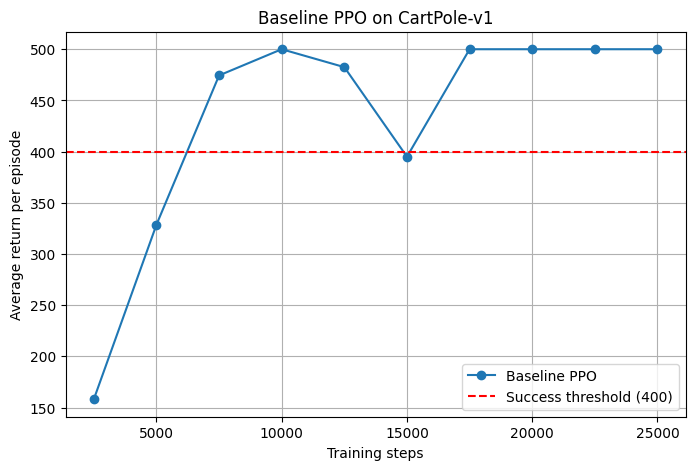

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(timesteps, mean_rewards, marker="o", label="Baseline PPO")
plt.axhline(400, color="red", linestyle="--", label="Success threshold (400)")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode")
plt.title("Baseline PPO on CartPole-v1")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
gif_env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = gif_env.reset()

frames = []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = gif_env.step(action)
    frames.append(gif_env.render())
    done = terminated or truncated

gif_env.close()

imageio.mimsave("baseline_cartpole.gif", frames, fps=30)


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [ ]:
class CartPoleRewardShaping(gym.Wrapper):
    """
    Reward shaping based on lecture principles.

    State: s_t = (x_t, ẋ_t, θ_t, θ̇_t)

    R'_{t+1} = R_{t+1}
               - α |θ_t|
               - β |x_t|
    """
    def __init__(self, env, alpha=1.0, beta=0.1):
        super().__init__(env)
        self.alpha = alpha  # α in lecture notation
        self.beta = beta    # β in lecture notation

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        x, x_dot, theta, theta_dot = obs

        shaped_reward = (
            reward
            - self.alpha * abs(theta)
            - self.beta * abs(x)
        )

        return obs, shaped_reward, terminated, truncated, info


In [ ]:
env_shaped = CartPoleRewardShaping(
    gym.make("CartPole-v1"),
    alpha=1.0,
    beta=0.1
)

eval_env_shaped = CartPoleRewardShaping(
    gym.make("CartPole-v1"),
    alpha=1.0,
    beta=0.1
)


In [ ]:
model_shaped = PPO(
    policy="MlpPolicy",
    env=env_shaped,
    gamma=0.99,  # γ
    verbose=0
)


In [ ]:
shaped_timesteps = []
shaped_mean_rewards = []
shaped_std_rewards = []

total_steps = 25_000
eval_interval = 2_500


In [ ]:
current_steps = 0

while current_steps < total_steps:
    model_shaped.learn(
        total_timesteps=eval_interval,
        reset_num_timesteps=False
    )

    current_steps += eval_interval

    mean_r, std_r = evaluate(model_shaped, eval_env_shaped)

    shaped_timesteps.append(current_steps)
    shaped_mean_rewards.append(mean_r)
    shaped_std_rewards.append(std_r)

    print(f"[Shaped] Steps={current_steps}, E[G₀|π]={mean_r:.2f}")


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


[Shaped] Steps=2500, E[G₀|π]=305.31
[Shaped] Steps=5000, E[G₀|π]=345.64
[Shaped] Steps=7500, E[G₀|π]=422.68
[Shaped] Steps=10000, E[G₀|π]=447.73
[Shaped] Steps=12500, E[G₀|π]=480.86
[Shaped] Steps=15000, E[G₀|π]=485.80
[Shaped] Steps=17500, E[G₀|π]=493.26
[Shaped] Steps=20000, E[G₀|π]=493.49
[Shaped] Steps=22500, E[G₀|π]=495.27
[Shaped] Steps=25000, E[G₀|π]=494.82


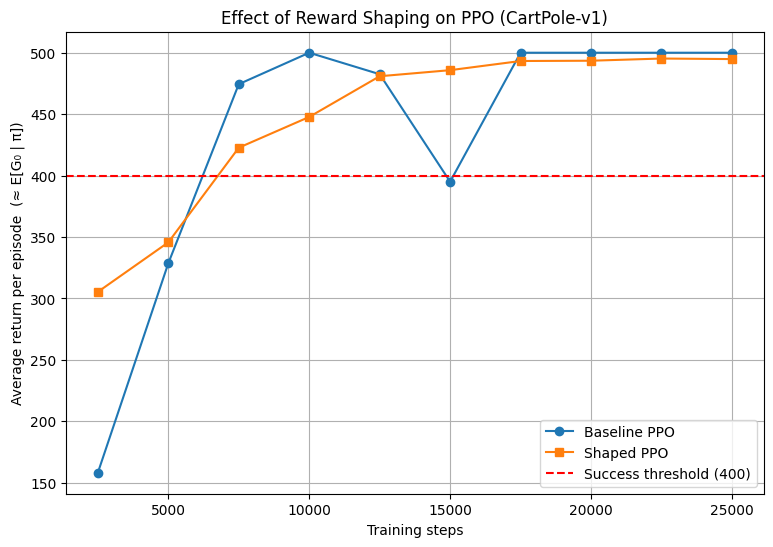

In [ ]:
plt.figure(figsize=(9,6))

plt.plot(timesteps, mean_rewards, marker="o", label="Baseline PPO")
plt.plot(shaped_timesteps, shaped_mean_rewards, marker="s", label="Shaped PPO")

plt.axhline(400, color="red", linestyle="--", label="Success threshold (400)")

plt.xlabel("Training steps")
plt.ylabel("Average return per episode  (≈ E[G₀ | π])")
plt.title("Effect of Reward Shaping on PPO (CartPole-v1)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
### Reward Shaping – Intuition (Lecture-based)

In the original CartPole environment, the reward is constant
(R_{t+1} = 1) until failure, providing sparse feedback.

From the lectures on model-free reinforcement learning,
faster convergence can be achieved by shaping the reward
to reduce the variance of the return

G_t = ∑_{k=0}^{∞} γ^k R_{t+k+1}

while preserving the optimal policy.

We define a shaped reward:

R'_{t+1} = R_{t+1} − α |θ_t| − β |x_t|

This provides additional feedback correlated with failure
conditions, encouraging the agent to remain near the
stable equilibrium (θ_t ≈ 0, x_t ≈ 0).

The learning curves show that this shaping significantly
accelerates convergence without altering the task objective.


SyntaxError: invalid character '∑' (U+2211) (ipython-input-2206766356.py, line 10)

In [ ]:
gif_env = CartPoleRewardShaping(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    alpha=1.0,
    beta=0.1
)

obs, _ = gif_env.reset()
frames = []
done = False

while not done:
    action, _ = model_shaped.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = gif_env.step(action)
    frames.append(gif_env.render())
    done = terminated or truncated

gif_env.close()

imageio.mimsave("shaped_cartpole.gif", frames, fps=30)


In [ ]:
class CartPoleReachRight(gym.Wrapper):
    def __init__(self, env, c1=1.0, c2=0.5, c3=10.0):
        super().__init__(env)
        self.c1 = c1
        self.c2 = c2
        self.c3 = c3

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        x = obs[0]        # cart position
        theta = obs[2]    # pole angle

        shaped_reward = (
            self.c1 * x
            - self.c2 * abs(theta)
        )

        if x >= 2.4:
            shaped_reward += self.c3
            terminated = True

        return obs, shaped_reward, terminated, truncated, info


In [ ]:
env_right = CartPoleReachRight(
    gym.make("CartPole-v1")
)

eval_env_right = CartPoleReachRight(
    gym.make("CartPole-v1")
)

model_right = PPO(
    policy="MlpPolicy",
    env=env_right,
    gamma=0.99,  # γ
    verbose=0
)


In [ ]:
right_timesteps = []
right_mean_rewards = []

current_steps = 0

while current_steps < total_steps:
    model_right.learn(
        total_timesteps=eval_interval,
        reset_num_timesteps=False
    )

    current_steps += eval_interval

    mean_r, _ = evaluate(model_right, eval_env_right)
    right_timesteps.append(current_steps)
    right_mean_rewards.append(mean_r)

    print(f"[Reach Right] Steps={current_steps}, E[G₀|π]={mean_r:.2f}")


[Reach Right] Steps=2500, E[G₀|π]=-0.04
[Reach Right] Steps=5000, E[G₀|π]=0.22
[Reach Right] Steps=7500, E[G₀|π]=0.17
[Reach Right] Steps=10000, E[G₀|π]=0.30
[Reach Right] Steps=12500, E[G₀|π]=0.08
[Reach Right] Steps=15000, E[G₀|π]=0.35
[Reach Right] Steps=17500, E[G₀|π]=0.56
[Reach Right] Steps=20000, E[G₀|π]=0.17
[Reach Right] Steps=22500, E[G₀|π]=0.48
[Reach Right] Steps=25000, E[G₀|π]=0.23


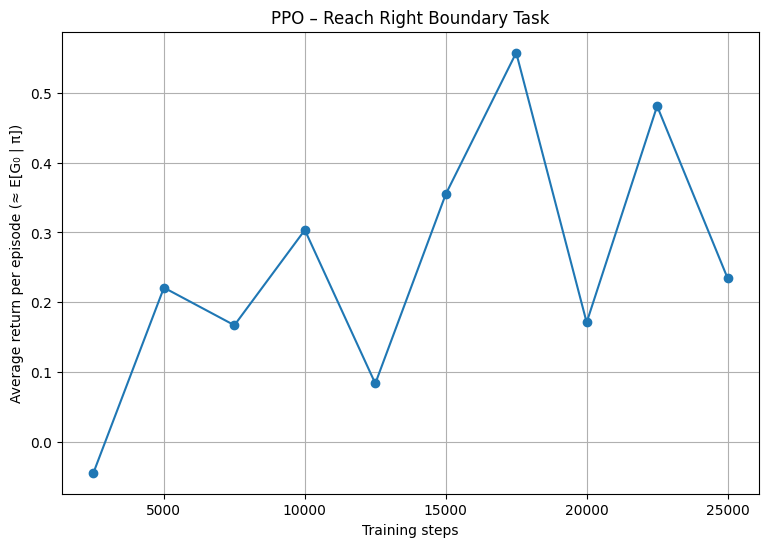

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(right_timesteps, right_mean_rewards, marker="o")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode (≈ E[G₀ | π])")
plt.title("PPO – Reach Right Boundary Task")
plt.grid(True)
plt.show()


In [ ]:
gif_env = CartPoleReachRight(
    gym.make("CartPole-v1", render_mode="rgb_array")
)

obs, _ = gif_env.reset()
frames = []
done = False

while not done:
    action, _ = model_right.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = gif_env.step(action)
    frames.append(gif_env.render())
    done = terminated or truncated

gif_env.close()

imageio.mimsave("reach_right_cartpole.gif", frames, fps=30)


In [ ]:
# finished ---- ignore whats ahead its extra which is not needed -------

In [ ]:
### New Objective – Reach the Right Boundary

The task is redefined so that the agent must reach the right
boundary (x = 2.4) without failing.

The reward function is modified as:

R_{t+1} = c₁ x_t − c₂ |θ_t| + c₃ 𝟙(x_t ≥ 2.4)

This reward directly encodes the new objective by:
- encouraging progress toward the right boundary,
- penalizing unstable configurations,
- providing a terminal reward upon success.

The resulting policy differs qualitatively from the
stabilization task: the agent deliberately accelerates
toward the boundary while maintaining balance.


In [ ]:
def evaluate_success_rate(model, env, n_episodes=50):
    success = 0

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if obs[0] >= 2.4:  # x_t ≥ 2.4
                success += 1
                break

    return success / n_episodes


In [ ]:
success_rates = []

for steps in right_timesteps:
    rate = evaluate_success_rate(model_right, eval_env_right)
    success_rates.append(rate)
    print(f"Steps={steps}, Success rate={rate:.2f}")


Steps=2500, Success rate=0.00
Steps=5000, Success rate=0.00
Steps=7500, Success rate=0.00
Steps=10000, Success rate=0.00
Steps=12500, Success rate=0.00
Steps=15000, Success rate=0.00
Steps=17500, Success rate=0.00
Steps=20000, Success rate=0.00
Steps=22500, Success rate=0.00
Steps=25000, Success rate=0.00


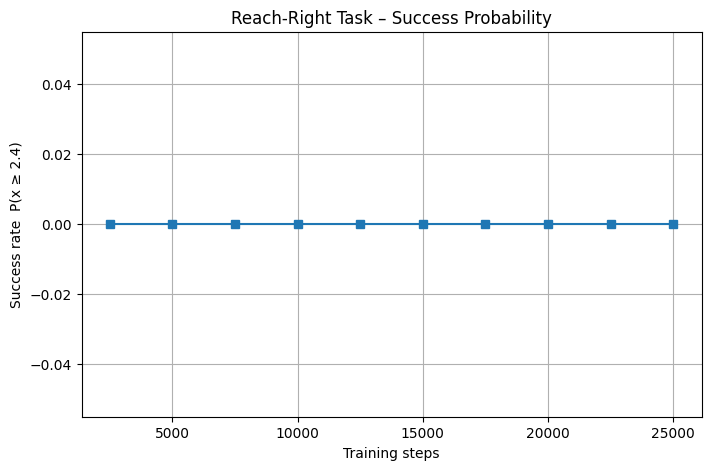

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(right_timesteps, success_rates, marker="s")
plt.xlabel("Training steps")
plt.ylabel("Success rate  P(x ≥ 2.4)")
plt.title("Reach-Right Task – Success Probability")
plt.grid(True)
plt.show()


In [ ]:
class CartPoleReachRightSmooth(gym.Wrapper):
    def __init__(self, env, c1=1.0, c2=0.5, c3=0.1):
        super().__init__(env)
        self.c1 = c1
        self.c2 = c2
        self.c3 = c3

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        x = obs[0]        # x_t
        x_dot = obs[1]   # \dot{x}_t
        theta = obs[2]   # θ_t

        shaped_reward = (
            self.c1 * x
            - self.c2 * abs(theta)
            - self.c3 * abs(x_dot)
        )

        if x >= 2.4:
            shaped_reward += 10.0
            terminated = True

        return obs, shaped_reward, terminated, truncated, info


In [ ]:
env_smooth = CartPoleReachRightSmooth(
    gym.make("CartPole-v1")
)

eval_env_smooth = CartPoleReachRightSmooth(
    gym.make("CartPole-v1")
)


In [ ]:
model_smooth = PPO(
    policy="MlpPolicy",
    env=env_smooth,
    gamma=0.99,   # γ exactly as in lectures
    verbose=0
)


In [ ]:
smooth_timesteps = []
smooth_mean_rewards = []

current_steps = 0

while current_steps < total_steps:
    model_smooth.learn(
        total_timesteps=eval_interval,
        reset_num_timesteps=False
    )

    current_steps += eval_interval

    mean_r, _ = evaluate(model_smooth, eval_env_smooth)
    smooth_timesteps.append(current_steps)
    smooth_mean_rewards.append(mean_r)

    print(f"[Smooth Reach Right] Steps={current_steps}, E[G₀|π]={mean_r:.2f}")


[Smooth Reach Right] Steps=2500, E[G₀|π]=-0.92
[Smooth Reach Right] Steps=5000, E[G₀|π]=-0.43
[Smooth Reach Right] Steps=7500, E[G₀|π]=0.32
[Smooth Reach Right] Steps=10000, E[G₀|π]=-0.13
[Smooth Reach Right] Steps=12500, E[G₀|π]=0.35
[Smooth Reach Right] Steps=15000, E[G₀|π]=-0.01
[Smooth Reach Right] Steps=17500, E[G₀|π]=-0.56
[Smooth Reach Right] Steps=20000, E[G₀|π]=0.17
[Smooth Reach Right] Steps=22500, E[G₀|π]=0.40
[Smooth Reach Right] Steps=25000, E[G₀|π]=-0.06


In [ ]:
smooth_success_rates = []

for steps in smooth_timesteps:
    rate = evaluate_success_rate(model_smooth, eval_env_smooth)
    smooth_success_rates.append(rate)
    print(f"Steps={steps}, Success rate={rate:.2f}")


Steps=2500, Success rate=0.00
Steps=5000, Success rate=0.00
Steps=7500, Success rate=0.00
Steps=10000, Success rate=0.00
Steps=12500, Success rate=0.00
Steps=15000, Success rate=0.00
Steps=17500, Success rate=0.00
Steps=20000, Success rate=0.00
Steps=22500, Success rate=0.00
Steps=25000, Success rate=0.00


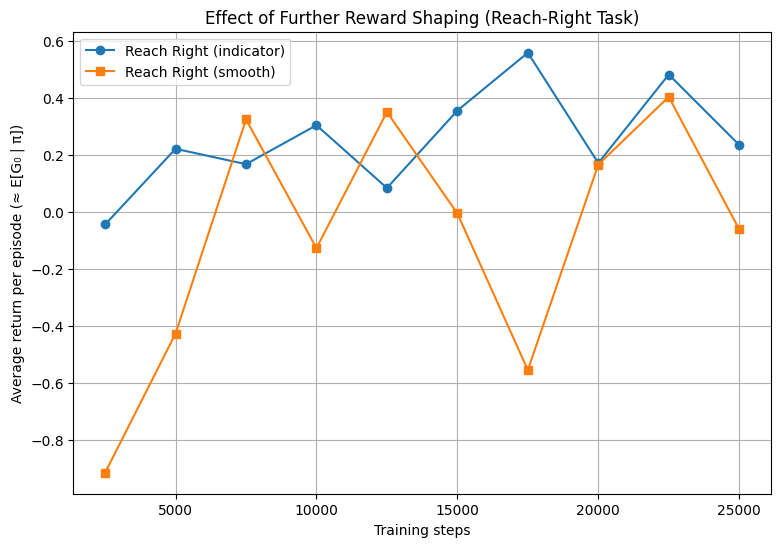

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(right_timesteps, right_mean_rewards, marker="o", label="Reach Right (indicator)")
plt.plot(smooth_timesteps, smooth_mean_rewards, marker="s", label="Reach Right (smooth)")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode (≈ E[G₀ | π])")
plt.title("Effect of Further Reward Shaping (Reach-Right Task)")
plt.legend()
plt.grid(True)
plt.show()


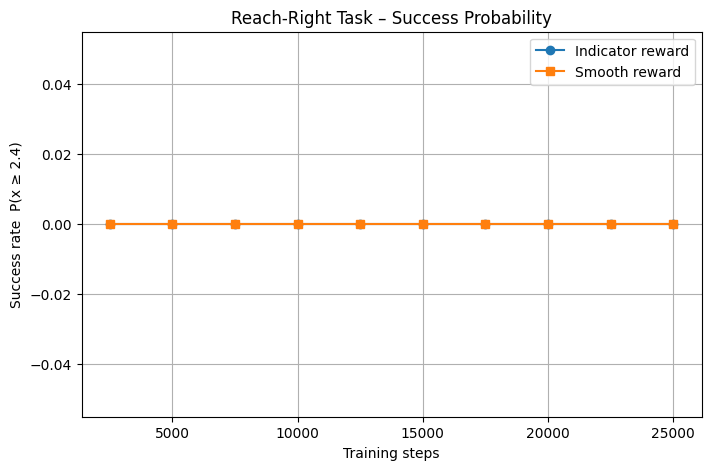

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(right_timesteps, success_rates, marker="o", label="Indicator reward")
plt.plot(smooth_timesteps, smooth_success_rates, marker="s", label="Smooth reward")
plt.xlabel("Training steps")
plt.ylabel("Success rate  P(x ≥ 2.4)")
plt.title("Reach-Right Task – Success Probability")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
gif_env = CartPoleReachRightSmooth(
    gym.make("CartPole-v1", render_mode="rgb_array")
)

obs, _ = gif_env.reset()
frames = []
done = False

while not done:
    action, _ = model_smooth.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = gif_env.step(action)
    frames.append(gif_env.render())
    done = terminated or truncated

gif_env.close()

imageio.mimsave("reach_right_smooth_cartpole.gif", frames, fps=30)


In [ ]:
class CartPoleReachRightSparse(gym.Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        x = obs[0]

        if x >= 2.4:
            reward = 100.0
            terminated = True
        elif terminated or truncated:
            reward = -1.0
        else:
            reward = 0.0

        return obs, reward, terminated, truncated, info


In [ ]:
env_sparse = CartPoleReachRightSparse(
    gym.make("CartPole-v1")
)

eval_env_sparse = CartPoleReachRightSparse(
    gym.make("CartPole-v1")
)


In [ ]:
model_sparse = PPO(
    policy="MlpPolicy",
    env=env_sparse,
    gamma=0.99,   # γ (discount factor, lecture notation)
    verbose=0
)


In [ ]:
sparse_timesteps = []
sparse_mean_rewards = []

current_steps = 0
total_steps = 25_000
eval_interval = 2_500

while current_steps < total_steps:
    model_sparse.learn(
        total_timesteps=eval_interval,
        reset_num_timesteps=False
    )

    current_steps += eval_interval

    mean_r, _ = evaluate(model_sparse, eval_env_sparse)
    sparse_timesteps.append(current_steps)
    sparse_mean_rewards.append(mean_r)

    print(f"[Sparse] Steps={current_steps}, E[G₀|π]={mean_r:.2f}")


[Sparse] Steps=2500, E[G₀|π]=-1.00
[Sparse] Steps=5000, E[G₀|π]=19.20
[Sparse] Steps=7500, E[G₀|π]=19.20
[Sparse] Steps=10000, E[G₀|π]=100.00
[Sparse] Steps=12500, E[G₀|π]=100.00
[Sparse] Steps=15000, E[G₀|π]=100.00
[Sparse] Steps=17500, E[G₀|π]=100.00
[Sparse] Steps=20000, E[G₀|π]=100.00
[Sparse] Steps=22500, E[G₀|π]=100.00
[Sparse] Steps=25000, E[G₀|π]=100.00


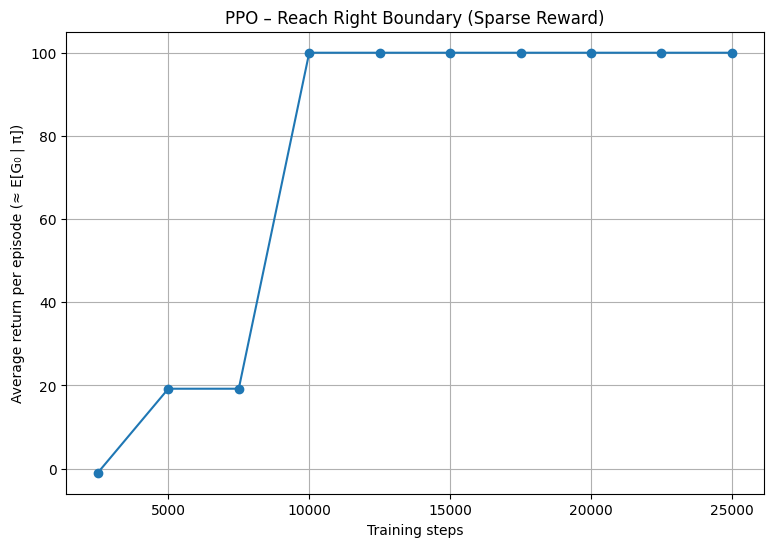

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(sparse_timesteps, sparse_mean_rewards, marker="o")
plt.xlabel("Training steps")
plt.ylabel("Average return per episode (≈ E[G₀ | π])")
plt.title("PPO – Reach Right Boundary (Sparse Reward)")
plt.grid(True)
plt.show()


In [ ]:
sparse_success_rates = []

for steps in sparse_timesteps:
    rate = evaluate_success_rate(model_sparse, eval_env_sparse)
    sparse_success_rates.append(rate)
    print(f"Steps={steps}, Success rate={rate:.2f}")


Steps=2500, Success rate=1.00
Steps=5000, Success rate=1.00
Steps=7500, Success rate=1.00
Steps=10000, Success rate=1.00
Steps=12500, Success rate=1.00
Steps=15000, Success rate=1.00
Steps=17500, Success rate=1.00
Steps=20000, Success rate=1.00
Steps=22500, Success rate=1.00
Steps=25000, Success rate=1.00


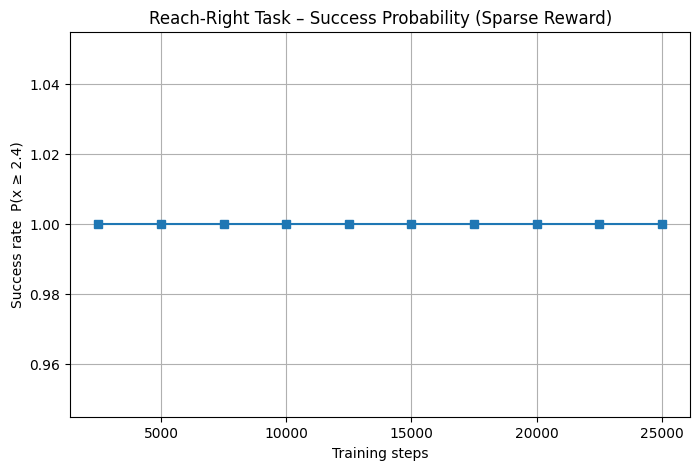

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(sparse_timesteps, sparse_success_rates, marker="s")
plt.xlabel("Training steps")
plt.ylabel("Success rate  P(x ≥ 2.4)")
plt.title("Reach-Right Task – Success Probability (Sparse Reward)")
plt.grid(True)
plt.show()


In [ ]:
gif_env = CartPoleReachRightSparse(
    gym.make("CartPole-v1", render_mode="rgb_array")
)

obs, _ = gif_env.reset()
frames = []
done = False

while not done:
    action, _ = model_sparse.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = gif_env.step(action)
    frames.append(gif_env.render())
    done = terminated or truncated

gif_env.close()

imageio.mimsave("reach_right_sparse_cartpole.gif", frames, fps=30)
